# Crash Severity Classification — XGBoost Training

Companion notebook to [`docs/ml/crash-severity-model-plan.md`](../docs/ml/crash-severity-model-plan.md).

**Dataset (v2):** [`generate_crash_dataset.py`](generate_crash_dataset.py) now simulates actual 2-second, 50Hz tri-axial accelerometer waveforms per class (baseline gravity + road vibration + a damped-oscillation impact event + sensor noise/saturation), then computes the 8 features from those simulated signals — rather than drawing the 8 target statistics directly from non-overlapping ranges (the v1 approach, which produced a trivially separable, 100%-accuracy dataset). Classes now genuinely overlap, especially minor vs. major at the boundary.

**Decisions locked in for this run:**
- No real (non-synthetic) accelerometer data is available — training/validation is entirely on the synthetic dataset in `xgboost_crash_dataset.csv`, treated as a v0 prototype (see plan doc §2 and §6 for caveats).
- The false-positive (pothole) class is dropped entirely — the generator now only produces 3 classes directly: `0 = Normal driving` (incl. potholes/bumps), `1 = Minor crash`, `2 = Major crash`.

**Requires:** `pandas`, `numpy`, `xgboost`, `scikit-learn`, `matplotlib` in the active kernel's environment (`conda activate crash-ml`).

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
DATA_PATH = "xgboost_crash_dataset.csv"
MODEL_OUT_PATH = "crash_severity_model.json"

FEATURE_COLS = ["max_mag", "mean_mag", "std_dev", "zero_cross", "max_x", "max_y", "max_z", "SMA"]

# Generator now produces these 3 classes directly (false-positive class removed at generation time)
CLASS_NAMES = {0: "normal", 1: "minor_crash", 2: "major_crash"}

## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows")
print("Class distribution:")
print(df["LABEL"].value_counts().sort_index().rename(index=CLASS_NAMES))

assert set(df["LABEL"].unique()) == {0, 1, 2}, "Unexpected label values — check generator output"

Loaded 7500 rows
Class distribution:
LABEL
normal         2500
minor_crash    2500
major_crash    2500
Name: count, dtype: int64


## 2. Stratified train/validation/test split (70/15/15)

Random split is safe here — rows are independent synthetic windows, no time-series leakage risk (see plan doc §3.1).

In [3]:
X = df[FEATURE_COLS]
y = df["LABEL"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
for name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name} distribution:", split_y.value_counts().sort_index().to_dict())

Train: 5250  Val: 1125  Test: 1125
train distribution: {0: 1750, 1: 1750, 2: 1750}
val distribution: {0: 375, 1: 375, 2: 375}
test distribution: {0: 375, 1: 375, 2: 375}


## 3. Baseline XGBoost model (3-class, `multi:softprob`)

In [4]:
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print("Training complete.")
print("Final train mlogloss:", model.evals_result()["validation_0"]["mlogloss"][-1])
print("Final val mlogloss:", model.evals_result()["validation_1"]["mlogloss"][-1])

Training complete.
Final train mlogloss: 0.02451246822130495
Final val mlogloss: 0.10422885196883969


## 4. Evaluation on held-out test set

Per the plan doc §3.4, recall on `minor_crash` and `major_crash` matters far more than overall accuracy — a false negative here means a real crash goes unflagged.

In [5]:
y_pred = model.predict(X_test)

target_names = ["normal", "minor_crash", "major_crash"]
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

              precision    recall  f1-score   support

      normal      0.979     1.000     0.989       375
 minor_crash      0.948     0.923     0.935       375
 major_crash      0.944     0.949     0.947       375

    accuracy                          0.957      1125
   macro avg      0.957     0.957     0.957      1125
weighted avg      0.957     0.957     0.957      1125



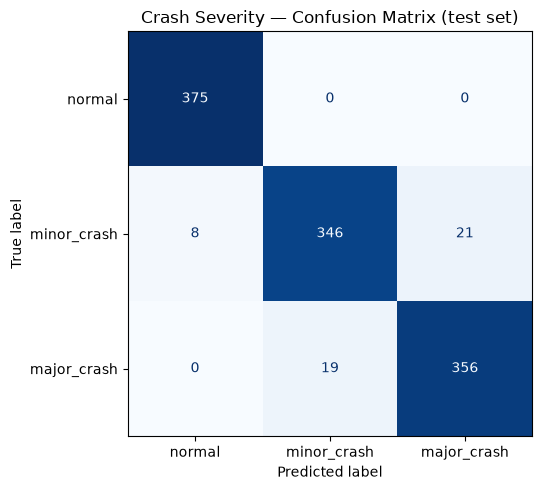

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Crash Severity — Confusion Matrix (test set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [7]:
# Worst-case failure mode: major crash (label 2) predicted as normal (label 0)
major_idx = y_test == 2
major_missed_as_normal = ((y_pred[major_idx.values] == 0)).sum()
print(f"Major crashes in test set: {major_idx.sum()}")
print(f"Major crashes misclassified as normal (worst case): {major_missed_as_normal}")

minor_idx = y_test == 1
minor_missed_as_normal = ((y_pred[minor_idx.values] == 0)).sum()
print(f"\nMinor crashes in test set: {minor_idx.sum()}")
print(f"Minor crashes misclassified as normal: {minor_missed_as_normal}")

Major crashes in test set: 375
Major crashes misclassified as normal (worst case): 0

Minor crashes in test set: 375
Minor crashes misclassified as normal: 8


## 5. Feature importance sanity check

Expect `std_dev` and `max_mag` to dominate over something like `zero_cross` alone — if not, worth investigating why.

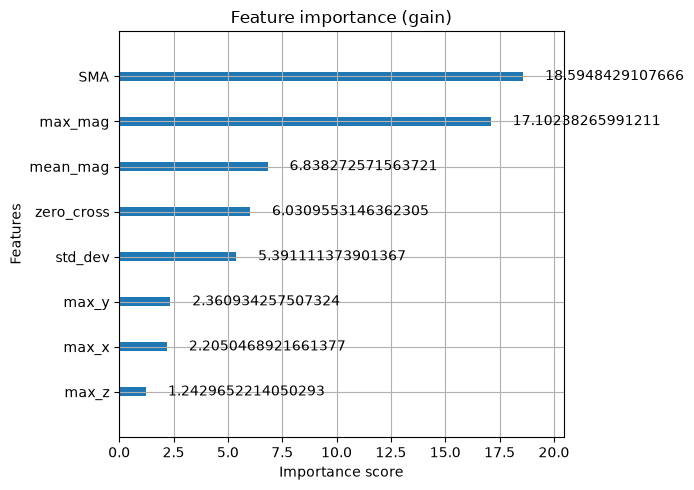

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
xgb.plot_importance(model, ax=ax, importance_type="gain", title="Feature importance (gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## 6. Save model artifact

Native XGBoost serialization — feature order contract is `FEATURE_COLS` above; anything computing features at inference time (the client-side windowing logic in `ble.js`, per the plan doc §4) must produce them in this exact order.

In [9]:
model.get_booster().save_model(MODEL_OUT_PATH)
print(f"Saved model to {MODEL_OUT_PATH}")
print(f"Feature order contract: {FEATURE_COLS}")
print(f"Class mapping: {CLASS_NAMES}")

Saved model to crash_severity_model.json
Feature order contract: ['max_mag', 'mean_mag', 'std_dev', 'zero_cross', 'max_x', 'max_y', 'max_z', 'SMA']
Class mapping: {0: 'normal', 1: 'minor_crash', 2: 'major_crash'}


## Next steps (not done in this notebook)

1. Convert `crash_severity_model.json` to ONNX for client-side inference via `onnxruntime-web` (see plan doc §4 — Option B, chosen direction).
2. Confirm whether the current ESP32 firmware transmits raw `x`/`y`/`z` per sample (needed to compute `max_x`/`max_y`/`max_z`/`SMA` client-side) or only a magnitude scalar — a firmware update may be a prerequisite.
3. Implement the 2-second rolling window + feature computation in `src/lib/ble.js`, replacing the `CRASH_THRESHOLD`/`MAJOR_THRESHOLD`/`MAJOR_CONSECUTIVE` logic.
4. Shadow-mode validation once wired up (see plan doc §6).